<a href="https://colab.research.google.com/github/nanna273/MLEndLS_AB/blob/main/ECS7020P_miniproject_advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECS7020P mini-project submission - advanced  

## MLEndLS London Sounds audio dataset - "was it *busy*?"

**Contents:**  
1 Author  
2 Problem formulation  
3 Machine Learning pipeline  
4 Transformation stage  
5 Modelling  
6 Methodology  
7 Dataset  
8 Results  
9 Conclusions

# 1 Author

**Student Name**:  Anna Burlingsby  
**Student ID**:  210900587



# 2 Problem formulation

London is a vibrant city, full of both natural and man-made noises. It is supposed that areas might be distinguished via recordings made in those areas.  

The areas selected for investigation in this notebook are museums and libraries. These are indoor spaces with similiar purposes, but there are different expectations of the noise levels depending on the place - for example, many children are encouraged to learn and interact at the Natural History Museum, whereas the British Library is likely to have fewer visitors, who are there for quiet contemplation.  

Classification of a selected subset of the MLEndLS dataset as *busy* or *not busy* is the purpose of this notebook. The subset that will be used is laid out below:  

***Busy*:**  

- Royal Festival Hall welcome hub (southbank, royal).
- Natural History Museum Hintze Hall (kensington, hintze).
- Natural History Museum Fossil Marine Reptiles gallery (kensington, marine).
- Natural History Museum Dinosaur gallery (kensington, dinosaur).

***Not busy*:**  

- British Museum, Great court (british, greatcourt).
- British Museum, Room 12 (british, room12).
- British Library main entrance (euston, library).
- British Library, John Ritblat gallery (euston, ritblat).
- The National Gallery Central Hall (westend, national).

# 3 Machine Learning pipeline

Broadly, the pipeline is divided into the following stages:  
1. Load data, where the raw data is brought into the notebook, and the relevant files are selected.
2. Transformation, where the audio files are processed to extract features.
4. Validation, where models are compared, hyperparamters tuned, and one model is selected.
3. Testing, where the selected model is tested before deployment.
6. Training, where the model is re-trained on the whole dataset.
4. Deployment (not covered in this notebook), where models are deployed on unseen data.  

Below, the libraries that will be used to address this problem are imported.

In [ ]:
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os, sys, re, pickle, glob
import urllib.request
import zipfile

import IPython.display as ipd
from tqdm import tqdm
import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_auc_score, roc_curve, recall_score
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 4 Transformation stage

## 4.1 Feature extraction  

The audio data available does not have, on its own, appropriate features for machine learning models. In addition, it is presented in the time domain, i.e. a series of amplitudes of sound against the timestamp.  

### 4.1.1 Basic features

Several basic features of each recording are extracted. The input for each of these is the audio recording, and the output is a single feature for each of the below.:  

- Overall power of the recording.
- Mean of the pitch of the recording.
- Standard deviation of the pitch.
- Fraction of the recording that is voiced.  

### 4.1.2 More advanced features  

The time series data can also be converted to the frequency domain with a Fast Fourier Transform (FFT). This presents a series of new audio features that can be extracted by the Python Librosa library. The below will be explored in this notebook. The input to each of them is the fourier transformed spectrum, and the output is a number of features as indicated:  

- Spectral contrast - 6 features
- Chroma - 13 features
- MFCC - 20 features
- RMS - 1 feature
- Spectral centroid - 1 feature
- Spectral bandwidth - 1 feature
- Spectral flatness - 1 feature
- Spectral rolloff - 1 feature.  

Due to the time constraints of producing this notebook, any further description of the meaning of each of the advanced features will not be conducted.  

## 4.2 Feature selection  

The combination of the extracted basic and advanced features will create 48 features in a dataset of 462 samples. While it may be possible to create a model with this many features, the so-called 'curse of dimensionality' means that there is a risk of overfitting, and therefore only a few features should be selected.  

The process of selection features in this notebook is to visualise the data using boxplots (with fliers/outliers hidden), and select the features that show distinction in their distributions between *busy* and *not busy* areas. This is conducted in section 7.6.2.  

The input into this stage is the 48 extracted features, and the output is a subset of these features as determined by the visualisation.

# 5 Modelling  

The training data will be z-score normalised before the model is applied, using the Python 'Standard Scaler'. The models tend to perform better with scaled data, because of how they calculate distances that are used to create classifiers.

A supervised machine learning problem has been presented in this notebook, as labels are available for the data. Unsupervised methods are likely to be considerably less accurate. The labels are also binary, and therefore, models should be selected that can make binary classifications of samples. The below models meet this criteria, and therefore will be explored in this notebook:
- Support Vector Machines (SVM)
- Logistic Regression
- Random Forest.  

The best performing (see section 6) of these models will then be selected to train the final model.

# 6 Methodology  

The subset of the data used is not balanced for the *busy* vs. *not busy* locations - there are 108 *busy* locations and 354 *not busy* locations (more than twice as many). Therefore, using the naive accuracy of a classifier as a quality metric will not give a good picture - for example, a classifier that classes all spots as *not busy* would have an accuracy of 77 %, which is misleadingly high. Therefore, models will be scored at all stages according to the ROC-AUC (receiver operating characteristic - area under curve). This works by moving the decision threshold for classification as positive (i.e. *busy*) and plotting the resulting TPR (true positive rate) and FPR (false positive rate). The AUC represents the area under the curve - a higher AUC represents a model that is better at making classifications.

## 6.1 Grid search  

The models from section 5 will have their hyperparameters tuned using grid search. As the dataset is unbalanced, the grid search will use the parameter *scoring='roc-auc'* to select the hyperparameters.  

## 6.2 Cross validation  

Cross-validation with 5 folds will then be used to select the best of the 3 models. Again, *scoring='roc-auc'* will be used for the K-fold model, so that the resulting scores are balanced by class.  The scores will be compared for each model, and the model with the highest score will be selected.

## 6.3 Threshold tuning  

Once the best model has been selected, the decision threshold should be tuned to give the best balance between TPR and FPR, as there is no reason to think that classifying as *busy* vs. *not busy* is more important. This will be used to adjust predictions.

## 6.4 Model training  

Once the best performing model has been selected, it will be trained on the whole available subset of data before deployment. The predictions will be altered according to the threshold value as calculated above. The overall accuracy score will be presented, as well as the precision, recall, and confusion matrix. These are used in preference to the overall accuracy as the dataset is unbalanced for *busy* vs. *not busy*.

# 7 Dataset  

## 7.1 Introduction to dataset

A dataset of audio recordings from around London has been collected by students at Queen Mary University of London (QMUL), and is called MLEndLS. The attributes of this raw data are:  
1. file_id - the name of the file e.g. '0001.wav' that will be used as an index.
2. area - the area of London where the file was recorded e.g. 'british' = The British Museum.
3. spot - the spot in the area where the recording was made e.g. 'street' = Great Russel Street.
4. in_out - whether the spot is 'indoor' or 'outdoor'.
5. Participant - the ID of the student who made the recording e.g. 'S151'.
6. Audio file recording - the .wav file that contains the approximately 7 second clip recorded by the participant.

The following is known about how the data was collected:  
- Participants were given the choice of 6 areas they could make recordings in.
- Each area contained 6 spots.
- Participants selected a minimum of 3 areas, and made recordings in all 6 spots of each of those areas. (note: one area, 'british' has only 5 spots, as the proposed spot 'room23' was inaccessible at the time of the recordings').

## 7.2 Uploading data to notebook  

Below, the filenames are loaded into the notebook and the number of MLEndLS audio files is checked.

In [ ]:
sample_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/*.wav'
files = glob.glob(sample_path)
len(files)

2497

There are 2500 files in the MLEndLS dataset, which has been manually chnaged to 2497 after the removal of 3 files. Two do not contain data (see section 7.3 below), and one is known to be a mislabelled location ('room13').

The attributes of each file have been provided in a .csv file, and are loaded into a dataframe below.

In [ ]:
MLEndLS_df = pd.read_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/MLEndLS.csv').set_index('file_id') 
MLEndLS_df

,area,spot,in_out,Participant
file_id,,,,
0001.wav,british,street,outdoor,S151
0002.wav,kensington,dinosaur,indoor,S127
0003.wav,campus,square,outdoor,S18
0004.wav,kensington,hintze,indoor,S179
0005.wav,campus,square,outdoor,S176
...,...,...,...,...
2496.wav,westend,trafalgar,outdoor,S151
2497.wav,campus,square,outdoor,S6
2498.wav,westend,national,indoor,S96


Below, the desired locations, as described in section 2 are selected, and the 'busy' vs. 'not busy' classification is added.  

In [ ]:
busy = ['kensingtonhintze', 'kensingtonmarine', 'kensingtondinosaur',
        'southbankroyal']
not_busy = ['britishgreatcourt', 'britishroom12', 'westendnational',
            'Eustonlibrary', 'Eustonritblat']
advanced_list = busy + not_busy

MLEndLS_df['area_spot'] = MLEndLS_df['area'] + MLEndLS_df['spot']
MLEndLS_df_a = MLEndLS_df.loc[MLEndLS_df['area_spot'].isin(advanced_list)]
MLEndLS_df_a['busy'] = MLEndLS_df_a['area_spot'].isin(busy)

MLEndLS_df_a

<ipython-input-5-e52ea57f955d>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MLEndLS_df_a['busy'] = MLEndLS_df_a['area_spot'].isin(busy)


,area,spot,in_out,Participant,area_spot,busy
file_id,,,,,,
0002.wav,kensington,dinosaur,indoor,S127,kensingtondinosaur,True
0004.wav,kensington,hintze,indoor,S179,kensingtonhintze,True
0013.wav,british,greatcourt,indoor,S66,britishgreatcourt,False
0019.wav,kensington,dinosaur,indoor,S82,kensingtondinosaur,True
0025.wav,british,room12,indoor,S52,britishroom12,False
...,...,...,...,...,...,...
2483.wav,kensington,dinosaur,indoor,S19,kensingtondinosaur,True
2491.wav,westend,national,indoor,S147,westendnational,False
2498.wav,westend,national,indoor,S96,westendnational,False


Summary statistics about the dataframe are presented below.

In [ ]:
MLEndLS_df_a.describe(include='all')

,area,spot,in_out,Participant,area_spot,busy
count,462,462,462,462,462,462
unique,5,9,1,169,9,2
top,british,national,indoor,S107,westendnational,False
freq,167,110,462,5,110,354


## 7.3 Data cleaning ##  

Some of the audio files do not contain any information. Below is some code that will identify these files, by opening them and using the librosa library to calculate the sum of their amplitude. Files with a zero amplitude are removed from the dataset.

In [ ]:
# Code was run once, presented in the notebook for completeness.
# for n, file in enumerate(files):
#   fs = None # Sampling frequency
#   x, fs = librosa.load(files[n], sr=fs)
#   empty_filenames = []
#   if x.sum() == 0:
#     print(file)

Output of above cell:  

```
/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/2206.wav  
/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/0033.wav
```

The empty files are '2206.wav' and '0033.wav'. These have manually been removed from the Google Drive folder.

The empty file in the non-existent 'room13' is identified as '0762.wav' below. It has also been manually removed.

In [ ]:
MLEndLS_df.loc[MLEndLS_df.spot=='room13']

,area,spot,in_out,Participant,area_spot
file_id,,,,,
0762.wav,british,room13,indoor,S71,britishroom13


In [ ]:
to_drop = ['2206.wav', '0033.wav', '0762.wav']
MLEndLS_df = MLEndLS_df.drop(to_drop)

In [ ]:
files_a = [file for file in files
                if file.split('/')[-1] in MLEndLS_df_a.index]

## 7.4 Data visualisation  

Below is a code cell that previews an audio file. The file shown is from a busy location, Natural History Museum Hintze Hall.

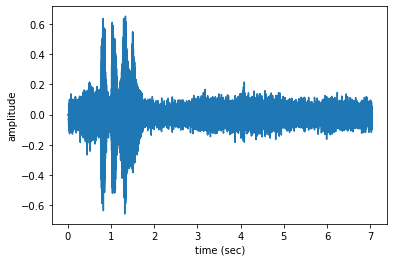

In [ ]:
n = 4
fs = None # Sampling frequency
fs = 22050
x, fs = librosa.load(files_a[n],sr=fs)
t = np.arange(len(x))/fs
plt.plot(t,x)
plt.xlabel('time (sec)')
plt.ylabel('amplitude')
plt.show()
display(ipd.Audio(files_a[n]))

According to the instructions, each audio file should contain the participant saying 'this is London' at the start of the recording. This can be seen in the above representative example as the considerably higher peaks early in the audio signal.  

Below, the signal undergoes a Fast Fourier Transform (FFT) to transfrom it into the frequency domain. The resulting frequency spectrum is displayed.

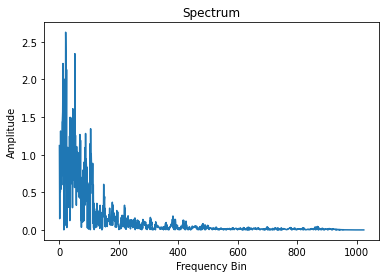

In [ ]:
n_fft = 2048
ft = np.abs(librosa.stft(x[:n_fft], hop_length=n_fft+1))
plt.plot(ft)
plt.title('Spectrum')
plt.xlabel('Frequency Bin')
plt.ylabel('Amplitude')
plt.show()

The FFT can be understood as some characteristic frequency peaks. The actual spectral frequency of each peak is not interpretable from the spectrum (it is an arbitrary scale), but this is not required for this ML classification problem.  

Below is shown the Mel spectrogram of the above audio file. This is described here in this link [https://analyticsindiamag.com/a-tutorial-on-spectral-feature-extraction-for-audio-analytics/].

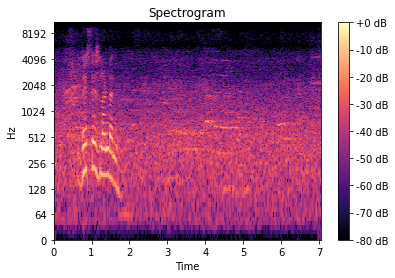

In [ ]:
spec = np.abs(librosa.stft(x, hop_length=512))
spec = librosa.amplitude_to_db(spec, ref=np.max)
librosa.display.specshow(spec, sr=fs, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.show()

The Mel spectrogram can be understood as an image of the data as it appears to human ears. One thing that is clear is that the data is not equivariate, and therefore a convolutional neural network should not be used on the raw data. However, the time domain should not be worked in (the time of sounds is arbitrary), and thus the sound should be transformed to the frequency domain for feature extraction.

## 7.5 Feature extraction  

The features that will be used to predict whether sound was recorded in *busy* or *not busy* locations are extracted from audio recordings.  

The code to extract the files will **not** execute every time the notebook is run, as it will take over 30 minutes. The extracted features have been saved in '.csv' files on a Google drive in section 7.5.3, which is later re-imported into the notebook in section 7.6.

### 7.5.1 Basic features  

First, the librosa library is used to extract the pitch, as well as the portions to the recording that contain voices.

In [ ]:
def getPitch(x,fs,winLen=0.02):
  #winLen = 0.02 
  p = winLen*fs
  frame_length = int(2**int(p-1).bit_length())
  hop_length = frame_length//2
  f0, voiced_flag, voiced_probs = librosa.pyin(y=x, fmin=80, fmax=450, sr=fs,
                                                 frame_length=frame_length,hop_length=hop_length)
  return f0,voiced_flag

In [ ]:
def getXy_basic(files,labels_file, scale_audio=False, onlySingleDigit=False):
  X_1, X_2, y =[], [], []
  for file in tqdm(files):
    fileID = file.split('/')[-1]
    file_name = file.split('/')[-1]
    yi = labels_file.loc[fileID]['busy']

    fs = None # if None, fs would be 22050
    x, fs = librosa.load(file,sr=fs)

    # Without scaled audio
    f0, voiced_flag = getPitch(x,fs,winLen=0.02)
      
    power = np.sum(x**2)/len(x)
    pitch_mean = np.nanmean(f0) if np.mean(np.isnan(f0))<1 else 0
    pitch_std  = np.nanstd(f0) if np.mean(np.isnan(f0))<1 else 0
    voiced_fr = np.mean(voiced_flag)

    xi1 = [power,pitch_mean,pitch_std,voiced_fr]
    X_1.append(xi1)

    # With scaled audio
    x = x/np.max(np.abs(x))
    f0, voiced_flag = getPitch(x,fs,winLen=0.02)
      
    power = np.sum(x**2)/len(x)
    pitch_mean = np.nanmean(f0) if np.mean(np.isnan(f0))<1 else 0
    pitch_std  = np.nanstd(f0) if np.mean(np.isnan(f0))<1 else 0
    voiced_fr = np.mean(voiced_flag)

    xi2 = [power,pitch_mean,pitch_std,voiced_fr]

    X_2.append(xi2)
    y.append(yi)

  return np.array(X_1), np.array(X_2), np.array(y)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# fileID = [file.split('/')[-1] for file in files_a]

In [ ]:
# Code was run once, presented in the notebook for completeness.
# X_1, X_2, y_1 = getXy_basic(files_a, labels_file=MLEndLS_df_a, scale_audio=True, onlySingleDigit=True)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_basic_scaled = pd.DataFrame(X_1, index=fileID)
# df_basic_scaled['busy'] = y_1
# df_basic_scaled = df_basic_scaled.rename(
#     columns={0:'power', 1:'pitch_mean', 2:'pitch_std', 3:'voiced_fr'})

# df_basic_unscaled = pd.DataFrame(X_2, index=fileID)
# df_basic_unscaled['busy'] = y_1
# df_basic_unscaled = df_basic_unscaled.rename(
#     columns={0:'power', 1:'pitch_mean', 2:'pitch_std', 3:'voiced_fr'})
# df_basic_unscaled

### 7.5.2 STFT  

A number of features can be extracted from the data via the librosa library. Due to the time constraints of this project, domain understanding of these will not be sought. Other methods will be used to determine useful potential features for model fitting. The 'librosa.feature' methods give a total of 44 potential features to investigate. The code is run twice, once with, and once without audio scaling. Both will be investigated.

In [ ]:
def getXy_STFT(files,labels_file, scale_audio=False):
  X,y =[],[]
  for file in tqdm(files):
    fileID = file.split('/')[-1]
    file_name = file.split('/')[-1]

    fs = 22050 # if None, fs would be 22050
    x, fs = librosa.load(file,sr=fs)
    if scale_audio: x = x/np.max(np.abs(x))
    n_fft = 2048
    ft = np.abs(librosa.stft(x[:n_fft], hop_length=n_fft+1))
    sc = librosa.feature.spectral_contrast(S=ft, sr=fs) # features 0-6
    ch = librosa.feature.chroma_stft(S=ft, sr=fs) # features 7-19
    mf = librosa.feature.mfcc(S=ft, sr=fs) # features 20-39
    rm = librosa.feature.rms(S=ft) # feature 40
    st = librosa.feature.spectral_centroid(S=ft, sr=fs) # feature 41
    sb = librosa.feature.spectral_bandwidth(S=ft, sr=fs) # features 42
    sf = librosa.feature.spectral_flatness(S=ft) # feature 43
    sr = librosa.feature.spectral_rolloff(S=ft, sr=fs) # feature 44

    features = [sc.T, ch.T, mf.T, rm.T, st.T, sb.T, sf.T, sr.T]

    xi = np.concatenate((features), axis=1)[0]

    X.append(xi)

  return np.array(X)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# X_3 = getXy_STFT(files_a, labels_file=MLEndLS_df_a, scale_audio=True)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_stft_scaled = pd.DataFrame(X_3,index=fileID)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# X_4 = getXy_STFT(files_a, labels_file=MLEndLS_df_a, scale_audio=False)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_stft_unscaled = pd.DataFrame(X_4, index=fileID)
# df_stft_unscaled

### 7.5.3 Combining features  

Below the basic and FFT features are combined into 2 dataframes, one with scaled audio and one without. Each of these is saved to a '.csv' file on the Google drive, so that repeated iterations of the notebook will not need to run the functions. The files have been manually renamed in the folder to avoid writing over them in error.

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_scaled = pd.concat([df_stft_scaled, df_basic_scaled], axis=1)
# df_scaled.to_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/scaled_features.csv')

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_unscaled = pd.concat([df_stft_unscaled, df_basic_unscaled], axis=1)
# df_unscaled.to_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/unscaled_features.csv')

## 7.6 Feature selection  

Not all the features will correlate with the target variable. 

First, the feature data is re-introduced to the notebook.

In [ ]:
scaled_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/scaled_features_a_221207.csv'
unscaled_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/unscaled_features_a_221207.csv'
df_scaled = pd.read_csv(scaled_path, index_col=0)
df_unscaled = pd.read_csv(unscaled_path, index_col=0)

The features extracted from both scaled and unscaled recordings are available at this point. There would be pros and cons to using each for the modelling. On the one hand, scaling the data might information about the amplitude that could be useful. On the other hand, not scaling the data might risk that the amplitude information is an artefact of the specific recording device. On balance, the features generated using unscaled data will be used for modelling.

In [ ]:
df_unscaled

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,power,pitch_mean,pitch_std,voiced_fr,busy
1506.wav,10.987165,20.339903,19.212850,13.528219,22.076296,25.539422,40.913780,0.838435,0.732121,0.678769,...,1.483665e-07,3003.053522,2554.330692,0.884327,5996.997070,0.002021,133.218089,5.272707,0.036364,False
1516.wav,27.171028,24.967471,24.425354,25.900981,22.705612,25.111566,26.409309,0.851757,0.838041,1.000000,...,7.648251e-03,1523.228172,1995.570541,0.003564,3003.881836,0.026493,215.337628,21.327012,0.051318,False
1531.wav,18.109955,14.275800,20.413946,17.777177,21.301632,28.000415,49.630094,0.930514,0.861072,0.831439,...,4.917125e-04,1418.050322,1643.669755,0.003061,3143.847656,0.002208,133.074084,21.050847,0.052531,False
1532.wav,21.984720,10.796778,16.865395,18.507653,25.763406,22.504553,34.512151,0.843230,0.814503,0.687101,...,1.768000e-02,1108.012758,1390.052970,0.000655,2153.320312,0.008542,124.728313,14.096215,0.065740,False
1534.wav,33.345977,19.193214,12.721722,29.251557,21.301903,23.192450,53.635134,0.767140,0.770380,1.000000,...,7.360834e-03,1314.161127,1725.312133,0.003005,2379.418945,0.012634,187.624612,27.794105,0.110379,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0472.wav,25.290737,21.802089,14.920692,16.327768,25.181922,23.223237,50.450801,0.878415,0.922825,0.722550,...,2.157327e-03,1801.729099,1953.064075,0.009404,3520.678711,0.009638,155.734005,25.552354,0.056730,True
0479.wav,19.277711,17.513755,20.038524,29.611686,24.582573,25.863803,36.496014,0.820287,0.584698,0.623987,...,1.307974e-02,1325.732246,1553.117503,0.000792,2853.149414,0.006745,204.073055,57.987995,0.059420,False
0483.wav,19.792759,9.966521,25.944634,19.047873,18.923113,25.313077,25.511533,0.784158,0.996292,0.669891,...,1.328110e-02,1870.791382,2161.930228,0.011552,3692.944336,0.015817,132.159882,8.819580,0.071429,False
0491.wav,17.697577,30.877082,28.484881,24.694003,27.406281,25.942732,53.662472,0.811939,1.000000,0.991419,...,8.386265e-03,1237.027666,1504.589535,0.000820,2336.352539,0.008435,254.176308,6.404413,0.025145,False


Below, histograms of each of the 48 variables are plotted, coloured by whether the spot is *busy* or *not busy*. Note that, due to the class imbalance, the y-scales for *busy* and *not busy* have been separated to show clearly the distributions in comparison.

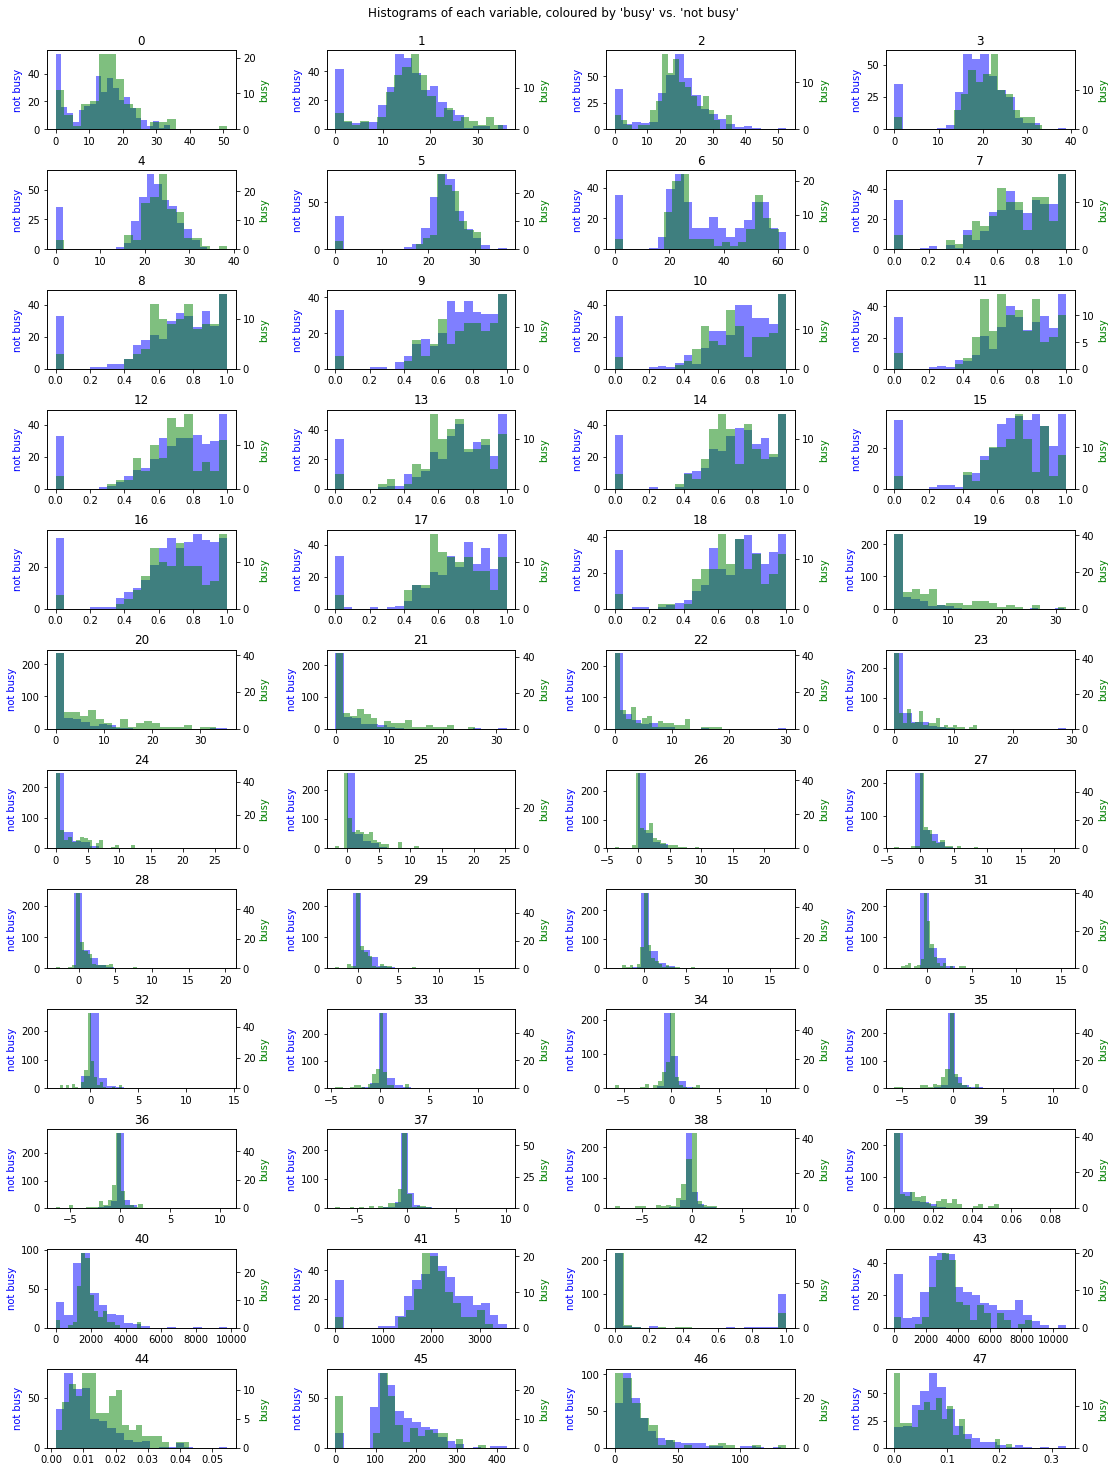

In [ ]:
fig, axs = plt.subplots(12, 4, figsize=(15,20))
fig.tight_layout(w_pad=6, h_pad=2)
fig.suptitle('Histograms of each variable, coloured by \'busy\' vs. \'not busy\'', y=1.02)

for i in range(48):
  ax1 = axs[i//4, i%4]
  ax2 = ax1.twinx()
  ax1.hist(df_unscaled.iloc[:,i].loc[df_unscaled['busy']==False],
                      bins=20, color='b', alpha=0.5)
  ax2.hist(df_unscaled.iloc[:,i].loc[df_unscaled['busy']==True],
                      bins=20, color='g', alpha=0.5)
  ax1.set_ylabel('not busy', color='b')
  ax2.set_ylabel('busy', color='g')
  ax1.set_title(i)

plt.show()

Possibly due to the scaling and influence of outliers, the histograms do not immediately show any clear differences between the *busy* vs. *not busy* classes.

### 7.6.1 Train test split  

To avoid data leakage, the dataset will be split before any further analysis or feature extraction. This will be stratified by the *busy* class - as there are more *not busy* than *busy* labels in the dataset, the proportions of each of these will be preserved in the train-test split.

In [ ]:
y = df_unscaled.pop('busy')

In [ ]:
X = np.array(df_unscaled)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, stratify=y, random_state=272)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((369, 48), (93, 48), (369,), (93,))

### 7.6.2 Visualisations for feature reductions  

Below are presented boxplots of each variable, separated by whether the spots are *busy* or *not busy*. Any significant difference in distribution has the potential to be exploited for feature selection. The outliers (fliers) have been hidden to reveal more information about the distributions of each variable.

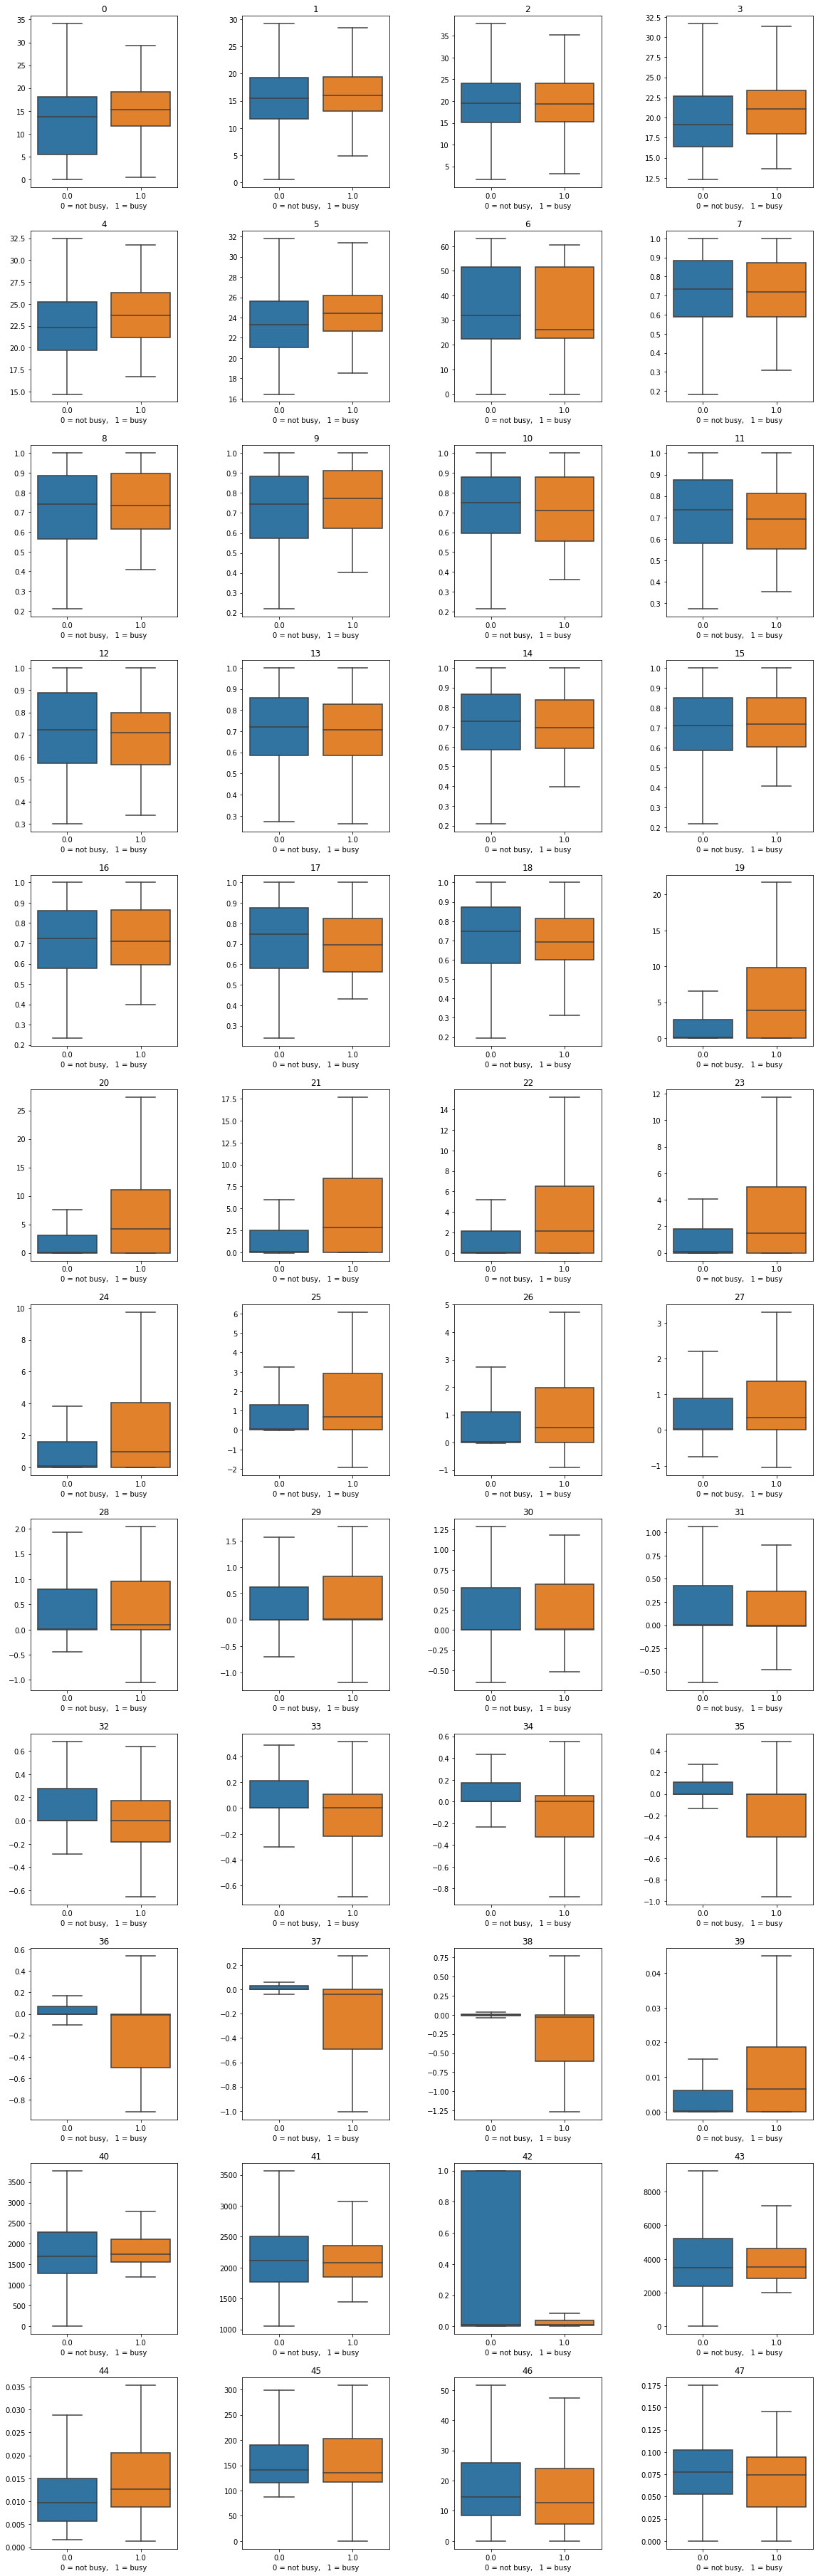

In [ ]:
data = pd.DataFrame(np.column_stack((X_train, y_train)))
data = data.rename(columns={48:'y'})

fig, axs = plt.subplots(12, 4, figsize=(16,50))
fig.tight_layout(w_pad=6, h_pad=4)

for i in range(48):
  ax = axs[i//4, i%4]
  sns.boxplot(data=data, y=i, x='y', ax=ax, showfliers=False)
  ax.set_ylabel('')
  ax.set_xlabel('0 = not busy,   1 = busy')
  ax.set_title(i)
plt.show()

There appears to be some correlation between 34-38 plus 42, and the target variable (as well as maybe 33, but less so). Therefore, modelling with only these features will be conducted.

In [ ]:
X_train_1 = X_train[:, [34, 35, 36, 37, 38, 42]]

# 8 Results

## 8.1 Model selection and validation  

### 8.1.1 Grid search  

The best parameters for each model will be selected using sklearn's grid search function. The search will be scored and re-fitted based on balanced accuracy.  

**For the SVM:**

In [ ]:
# defining parameter range
param_grid = {
    'classifier__C': [0.1, 1, 10, 100, 1000],
    'classifier__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'classifier__kernel': ['rbf']
    }

pipe = Pipeline(steps = [('scaler', StandardScaler()),
                         ('classifier', svm.SVC())])

grid = GridSearchCV(pipe, param_grid, refit=True, verbose=0, cv=3,
                    scoring='roc_auc')

In [ ]:
# fitting the model for grid search
grid.fit(X_train_1, y_train)

# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'classifier__C': 1000, 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf'}
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(C=1000, gamma=0.001))])


**For the Random Forest:**

In [ ]:
# defining parameter range
param_grid = {
    'classifier__max_depth': [2, 5, 10, 20, 50],
    'classifier__n_estimators': [10, 50, 100, 200, 500]
    }

pipe = Pipeline(steps = [('scaler', StandardScaler()),
                         ('classifier', RandomForestClassifier())])

grid = GridSearchCV(pipe, param_grid, refit=True, verbose=0, cv=3,
                    scoring='roc_auc')
  
# fitting the model for grid search
_ = grid.fit(X_train_1, y_train)

In [ ]:
# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'classifier__max_depth': 5, 'classifier__n_estimators': 500}
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(max_depth=5, n_estimators=500))])


**For the Logistic Regression:**

In [ ]:
# defining parameter range
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
    }

pipe = Pipeline(steps = [('scaler', StandardScaler()),
                         ('classifier', LogisticRegression(
                             solver='liblinear'))])

grid = GridSearchCV(pipe, param_grid, refit=True, verbose=0, cv=3,
                    scoring='roc_auc')
  
# fitting the model for grid search
_ = grid.fit(X_train_1, y_train)

In [ ]:
# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'classifier__C': 100, 'classifier__penalty': 'l1'}
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=100, penalty='l1', solver='liblinear'))])


In [ ]:
# Parameters for SVC
C_1 = 1000
gamma_1 = 0.001
# Parameters for Random Forest
max_depth = 5
n_estimators = 500
# Parameters for Logistic Regression
C = 100
penalty = 'l1'
# Parameters for cross-validation
cv = 5
scoring = 'roc_auc'

### 8.1.2 Cross-validation  

Several machine learning models are compared using cross-validation. 5 folds are used for each model 

In [ ]:
classifiers = {'SVC' : svm.SVC(
                   C=C_1, gamma=gamma_1),
               'Random Forest' : RandomForestClassifier(
                   max_depth=max_depth, n_estimators=n_estimators),
               'Logistic Regression' : LogisticRegression(
                   solver='liblinear', C=C, penalty=penalty)}

print('For the 6 selected variables:')
for key, clf in classifiers.items():
  pipe = Pipeline(steps = [('scaler', StandardScaler()), ('classifier', clf)])
  scores = cross_val_score(pipe, X_train_1, y_train, cv=cv, scoring=scoring)
  print('The cross-validation scores for', key, 'are:')
  print(scores)
  print(f'(mean = {scores.mean():.3f})')
  print(f'(standard deviation = {scores.std():.3f})')

For the 6 selected variables:
The cross-validation scores for SVC are:
[0.5327381  0.79876161 0.5877193  0.78637771 0.65021008]
(mean = 0.671)
(standard deviation = 0.106)
The cross-validation scores for Random Forest are:
[0.61904762 0.79050568 0.69762642 0.76986584 0.74894958]
(mean = 0.725)
(standard deviation = 0.061)
The cross-validation scores for Logistic Regression are:
[0.67361111 0.73168215 0.56811146 0.7131063  0.67857143]
(mean = 0.673)
(standard deviation = 0.057)


The Random Forest model has the best AUC of the ROC curve with the lowest standard deviation, of around an average of 0.72, and therefore will be tested and subsequently deployed. However, the threshold value will first need to be selected using the ROC curve.  

### 8.1.3 Threshold tuning using the ROC

The preference is for the model to make classifications that correctly select *busy* and *not busy* at approximately the same rate. With the ROC curve, this means that the TPR (true positive rate) and 1 - FPR (false positive rate) are approximately equal.  

Below, the model is fitted so it can be investigated with the ROC curve to find a better threshold value.

In [ ]:
sc = StandardScaler().fit(X_train_1)
rfc = RandomForestClassifier(max_depth=max_depth, n_estimators=n_estimators)
X_train_scaled = sc.transform(X_train_1)
clf.fit(X_train_scaled, y_train)
yt_p = clf.predict(X_train_scaled)

In [ ]:
print('The confusion matrix for the training data is:')
print(confusion_matrix(y_train, yt_p))
print()
print('The classification report for the training data is:')
print(classification_report(y_train, yt_p))

The confusion matrix for the training data is:
[[278   5]
 [ 72  14]]

The classification report for the training data is:
              precision    recall  f1-score   support

       False       0.79      0.98      0.88       283
        True       0.74      0.16      0.27        86

    accuracy                           0.79       369
   macro avg       0.77      0.57      0.57       369
weighted avg       0.78      0.79      0.74       369



From the above confusion matrix and scoring, it can be seen that without adjustment, the classifier is mostly incorrectly classifying the *busy* audio files.  

Below, the ROC curve for the Random Forest is plotted:

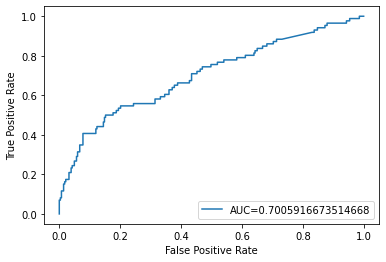

In [ ]:
probs = clf.predict_proba(X_train_scaled)
# Keep only positive predictions
probs = probs[:, 1]
fpr, tpr, threshold = roc_curve(y_train,  probs)
auc = roc_auc_score(y_train, probs)

#create ROC curve
plt.plot(fpr, tpr, label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

From visual inspection of the ROC curve, an FPR of around 0.4 seems to have the TPR and FPR roughly balanced. Below, this is used to get a threshold probability to use with the algorithm. The function is adapted from one found on stack overflow, and works by finding the point where the TPR and 1-FPR are roughly equal, then getting the corresponding threshold [https://stackoverflow.com/questions/28719067/roc-curve-and-cut-off-point-python]:

In [ ]:
def Find_Optimal_Cutoff(target, predicted):
    """ Find the optimal probability cutoff point for a classification model related to event rate
    Parameters
    ----------
    target : Matrix with dependent or target data, where rows are observations

    predicted : Matrix with predicted data, where rows are observations

    Returns
    -------     
    list type, with optimal cutoff value
        
    """
    fpr, tpr, threshold = roc_curve(target, predicted)
    i = np.arange(len(tpr)) 
    roc = pd.DataFrame({'tf' : pd.Series(tpr-(1-fpr), index=i), 'threshold' : pd.Series(threshold, index=i)})
    roc_t = roc.iloc[(roc.tf-0).abs().argsort()[:1]]

    return list(roc_t['threshold']) 

# Find optimal probability threshold
threshold = Find_Optimal_Cutoff(y_train, probs)
print(threshold)

[0.23288518369249855]


Therefore, a threshold of 0.23 will be used. Below, the corrected predictions for *busy* vs. *not busy* are calculated with this new threshold.

In [ ]:
threshold = 0.23
y_threshold = np.array([prob > threshold for prob in probs])

In [ ]:
print('The confusion matrix for the adjusted predictions is:')
print(confusion_matrix(y_train, y_threshold))
print()
print('The classification report for the adjusted predictions is:')
print(classification_report(y_train, y_threshold))

The confusion matrix for the adjusted predictions is:
[[174 109]
 [ 30  56]]

The classification report for the adjusted predictions is:
              precision    recall  f1-score   support

       False       0.85      0.61      0.71       283
        True       0.34      0.65      0.45        86

    accuracy                           0.62       369
   macro avg       0.60      0.63      0.58       369
weighted avg       0.73      0.62      0.65       369



## 8.2 Testing  

The selected model (Random Forest) will now be tested against the 20% separated data. The predictions are corrected according to the calculated threshold.

In [ ]:
sc = StandardScaler().fit(X_train_1)
clf = RandomForestClassifier(max_depth=max_depth, n_estimators=n_estimators)

X_train_scaled = sc.transform(X_train_1)
clf.fit(X_train_scaled, y_train)

X_test_1 = X_test[: ,[34, 35, 36, 37, 38, 42]]
X_test_scaled = sc.transform(X_test_1)

yt_p = clf.predict_proba(X_train_scaled)
yt_p_threshold = np.array([prob > threshold for prob in yt_p])[:, 1]
yv_p = clf.predict_proba(X_test_scaled)
yv_p_threshold = np.array([prob > threshold for prob in yv_p])[:, 1]

In [ ]:
print('The confusion matrix for the training data is:')
print(confusion_matrix(y_train, yt_p_threshold))
print()
print('The classification report for the training data is:')
print(classification_report(y_train, yt_p_threshold))
print()
print('The confusion matrix for the test data is:')
print(confusion_matrix(y_test, yv_p_threshold))
print()
print('The classification report for the test data is:')
print(classification_report(y_test, yv_p_threshold))

The confusion matrix for the training data is:
[[251  32]
 [ 19  67]]

The classification report for the training data is:
              precision    recall  f1-score   support

       False       0.93      0.89      0.91       283
        True       0.68      0.78      0.72        86

    accuracy                           0.86       369
   macro avg       0.80      0.83      0.82       369
weighted avg       0.87      0.86      0.87       369


The confusion matrix for the test data is:
[[49 22]
 [ 9 13]]

The classification report for the test data is:
              precision    recall  f1-score   support

       False       0.84      0.69      0.76        71
        True       0.37      0.59      0.46        22

    accuracy                           0.67        93
   macro avg       0.61      0.64      0.61        93
weighted avg       0.73      0.67      0.69        93



From the confusion matrices and classification reports, it can be seen that the model is still much better at classifying *not busy* (False) samples than *busy* (True) samples, but is now providing more balanced results.

## 8.3 Training for deployment  

Below, the model is trained on the whole dataset, and can be deployed.

In [ ]:
X_1 = X[: ,[34, 35, 36, 37, 38, 42]]
X_final = StandardScaler().fit_transform(X_1)
model = RandomForestClassifier(max_depth=max_depth, n_estimators=n_estimators)
model.fit(X_final,y)

yf_p = clf.predict_proba(X_final)
yf_p_threshold = np.array([prob > threshold for prob in yf_p])[:, 1]

In [ ]:
print('The confusion matrix for the model is:')
print(confusion_matrix(y, yf_p_threshold))
print()
print('The classification report for the model is:')
print(classification_report(y, yf_p_threshold))

The confusion matrix for the model is:
[[280  74]
 [ 44  64]]

The classification report for the model is:
              precision    recall  f1-score   support

       False       0.86      0.79      0.83       354
        True       0.46      0.59      0.52       108

    accuracy                           0.74       462
   macro avg       0.66      0.69      0.67       462
weighted avg       0.77      0.74      0.75       462



From the above report, using the threshold of 0.23 gives an overall accuracy of 0.74, where it classifies the *not busy* samples correctly 83 % of the time and the *busy* samples correctly 52 % of the time. The TPR and FPR are balanced for the classifier.

# 9 Conclusions

The classifier seems to be moderately successful at identifying the *busy* vs. *not busy* indoor spaces. However, it is 1.7x better at classifying the *not busy* audio files than the *busy* ones, likely because the dataset contains more *not busy* files.

Further areas for development could be:  
- Deeper understanding of extracted features (domain knowledge of sound analysis would be useful here).
- Collecting further recordings of different indoor spaces to extend classification.
- More nuanced inspection of the *busy* vs. *not busy* labels assigned to the locations.